# UQ Evaluation Metrics

Proper evaluation of UQ requires specialized metrics beyond accuracy. A model can be accurate but poorly calibrated (overconfident), or well-calibrated but imprecise (too wide intervals).

**Calibration:** Do 90% confidence intervals contain 90% of true values?
**Sharpness:** How tight are the intervals? (Narrower = better, given calibration)
**Scoring Rules:** Proper scoring rules (NLL, CRPS) jointly reward calibration + sharpness.
**OOD Detection:** Can uncertainty distinguish in-distribution from out-of-distribution?
**Selective Prediction:** Does rejecting high-uncertainty predictions improve reliability?

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.metrics import (
    prediction_interval_coverage,
    negative_log_likelihood,
    continuous_ranked_probability_score,
    interval_score,
    auroc_ood,
    fpr_at_tpr,
    aurc,
    risk_coverage_curve,
)
from deepuq.models import MLP
from deepuq.methods.mc_dropout import MCDropoutWrapper

## Setup: Train Model with UQ

In [2]:
# Generate data
np.random.seed(42)
torch.manual_seed(42)

X = np.linspace(-3, 3, 200).reshape(-1, 1)
y = np.sin(X) + 0.1 * X**2 + np.random.randn(*X.shape) * 0.1

X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)

# Train a model with dropout for MC Dropout UQ
model = MLP(1, [64, 64], 1, p_drop=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(500):
    optimizer.zero_grad()
    pred = model(X_train)
    loss = torch.nn.functional.mse_loss(pred, y_train)
    loss.backward()
    optimizer.step()

ensemble = MCDropoutWrapper(model, n_mc=20, apply_softmax=False)

# Get predictions
X_test = torch.tensor(np.linspace(-3, 3, 100).reshape(-1, 1), dtype=torch.float32)
y_test = torch.tensor(np.sin(X_test.numpy()) + 0.1 * X_test.numpy()**2 + np.random.randn(100, 1) * 0.1, dtype=torch.float32)

result = ensemble.predict_uq(X_test)
mean = result.mean.squeeze()
std = result.total_var.sqrt().squeeze()
print(f"Predictions: mean shape={mean.shape}, std shape={std.shape}")

Predictions: mean shape=torch.Size([100]), std shape=torch.Size([100])


## Calibration Metrics

Calibration measures whether stated confidence levels match empirical coverage. The Prediction Interval Coverage Probability (PICP) at level α should equal α for a perfectly calibrated model. A calibration curve plotting expected vs. observed coverage reveals systematic over- or under-confidence.

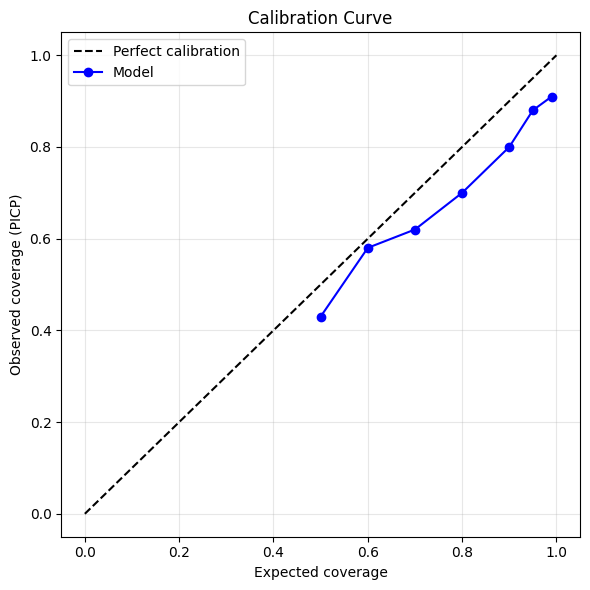

Calibration results:
  50% interval: PICP = 0.430
  60% interval: PICP = 0.580
  70% interval: PICP = 0.620
  80% interval: PICP = 0.700
  90% interval: PICP = 0.800
  95% interval: PICP = 0.880
  99% interval: PICP = 0.910


In [3]:
# Compute PICP at different confidence levels
from scipy.stats import norm

confidence_levels = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
picp_values = []

for alpha in confidence_levels:
    z = norm.ppf((1 + alpha) / 2)
    lower = mean - z * std
    upper = mean + z * std
    picp = prediction_interval_coverage(lower.numpy(), upper.numpy(), y_test.squeeze().numpy())
    picp_values.append(picp)

# Plot calibration curve
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(confidence_levels, picp_values, "bo-", label="Model")
plt.xlabel("Expected coverage")
plt.ylabel("Observed coverage (PICP)")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Calibration results:")
for alpha, picp in zip(confidence_levels, picp_values):
    print(f"  {alpha*100:.0f}% interval: PICP = {picp:.3f}")

## Scoring Rules

Proper scoring rules assign a single number summarizing predictive quality. **NLL** (Negative Log-Likelihood) penalizes both miscalibration and lack of sharpness under a Gaussian assumption. **CRPS** (Continuous Ranked Probability Score) generalizes MAE to full predictive distributions. **Interval Score** penalizes intervals that are too wide or miss the true value.

In [4]:
# Compute scoring rules
nll = negative_log_likelihood(mean.numpy(), (std**2).numpy(), y_test.squeeze().numpy())
crps = continuous_ranked_probability_score(mean.numpy(), std.numpy(), y_test.squeeze().numpy())

z90 = norm.ppf(0.95)
lower_90 = mean - z90 * std
upper_90 = mean + z90 * std
is_90 = interval_score(lower_90.numpy(), upper_90.numpy(), y_test.squeeze().numpy(), alpha=0.1)

print("Scoring Rules:")
print(f"{'Metric':<20} {'Value':<10}")
print("-" * 30)
print(f"{'NLL':<20} {nll:.4f}")
print(f"{'CRPS':<20} {crps:.4f}")
print(f"{'Interval Score (90%)':<20} {is_90:.4f}")

Scoring Rules:
Metric               Value     
------------------------------
NLL                  -0.5665
CRPS                 0.0163
Interval Score (90%) 0.5609


## OOD Detection

Out-of-distribution detection tests whether the model's uncertainty is higher for inputs far from the training distribution. AUROC measures how well uncertainty separates ID from OOD samples; FPR@95 reports the false positive rate when 95% of OOD points are detected.

OOD Detection Results:
  AUROC: 0.9994
  FPR@95% TPR: 0.0000


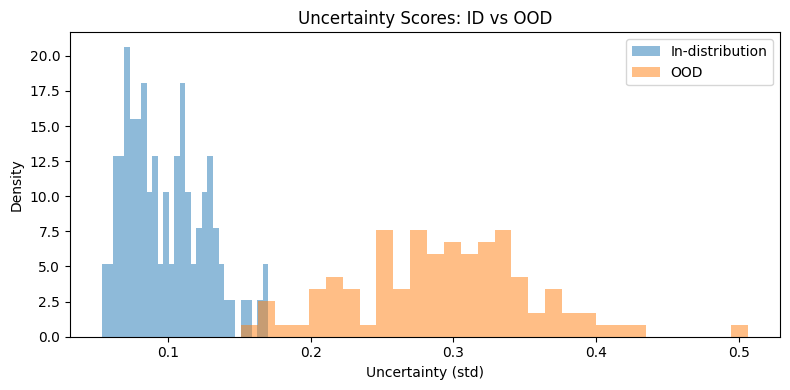

In [5]:
# In-distribution data
X_id = torch.tensor(np.random.uniform(-3, 3, (100, 1)), dtype=torch.float32)
result_id = ensemble.predict_uq(X_id)
std_id = result_id.total_var.sqrt().squeeze()

# OOD data (outside training range)
X_ood = torch.tensor(np.random.uniform(5, 8, (100, 1)), dtype=torch.float32)
result_ood = ensemble.predict_uq(X_ood)
std_ood = result_ood.total_var.sqrt().squeeze()

# Use uncertainty as OOD score
scores_id = std_id.numpy().ravel()
scores_ood = std_ood.numpy().ravel()

# Compute OOD detection metrics
auroc_val = auroc_ood(scores_id, scores_ood)
fpr95 = fpr_at_tpr(scores_id, scores_ood, tpr=0.95)

print(f"OOD Detection Results:")
print(f"  AUROC: {auroc_val:.4f}")
print(f"  FPR@95% TPR: {fpr95:.4f}")

# Visualize score distributions
plt.figure(figsize=(8, 4))
plt.hist(scores_id, bins=30, alpha=0.5, label="In-distribution", density=True)
plt.hist(scores_ood, bins=30, alpha=0.5, label="OOD", density=True)
plt.xlabel("Uncertainty (std)")
plt.ylabel("Density")
plt.title("Uncertainty Scores: ID vs OOD")
plt.legend()
plt.tight_layout()
plt.show()

## Selective Prediction Metrics

Selective prediction (reject option) withholds predictions when uncertainty is high. The **AURC** (Area Under the Risk-Coverage curve) measures how much risk decreases as we reject the most uncertain predictions. Lower AURC means uncertainty is a better indicator of likely errors.

AURC: 0.0119


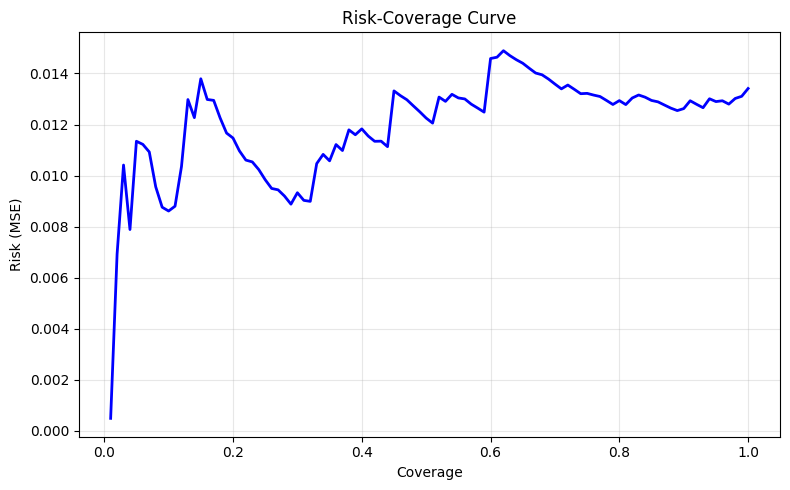


Selective prediction: rejecting uncertain predictions reduces risk
  Risk at 100% coverage: 0.0134
  Risk at 80% coverage: 0.0128
  Risk at 50% coverage: 0.0121


In [6]:
# Compute AURC and plot risk-coverage curve
errors = ((mean - y_test.squeeze())**2).numpy()
uncertainties = std.numpy()
aurc_val = aurc(uncertainties, errors)
coverages, risks = risk_coverage_curve(uncertainties, errors)

print(f"AURC: {aurc_val:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(coverages, risks, "b-", linewidth=2)
plt.xlabel("Coverage")
plt.ylabel("Risk (MSE)")
plt.title("Risk-Coverage Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSelective prediction: rejecting uncertain predictions reduces risk")
print(f"  Risk at 100% coverage: {risks[-1]:.4f}")
print(f"  Risk at 80% coverage: {risks[int(0.8*len(risks))]:.4f}")
print(f"  Risk at 50% coverage: {risks[int(0.5*len(risks))]:.4f}")